In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import plotly.graph_objects as go
# from tqdm import tqdm
from network_funcs import *
from qopt_funcs import *
import networkx as nx
# import random
import time
import shutil    # to copy files at the end of the script

# DV and CV key rates

In [ ]:
from qopt_funcs import *

func_CV = lambda dist : hybrid_keyrate_bitpersec(state_of_the_art_params, dist, d_hybrid = float('inf'))
# d_c_CV = bisection_solver(func_CV, 10E-06, d_max)            # not starting from 0 bc if T=1 there is a division by 0
func_DV = lambda dist : hybrid_keyrate_bitpersec(state_of_the_art_params, dist, d_hybrid = 0)
# d_c_DV = bisection_solver(func_DV, 10E-06, d_max)
diff = lambda d: func_CV(d) - func_DV(d)
d_cross = bisection_solver(diff, 10E-06, 1000)
d_cross

91.12686827681125

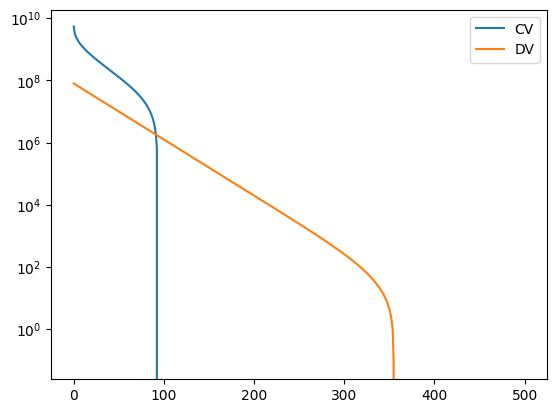

In [ ]:
xs = np.linspace(0.01, 500, 500)
plt.plot(xs, [func_CV(x) for x in xs], label='CV')
plt.plot(xs, [func_DV(x) for x in xs], label='DV')
plt.legend()
plt.yscale('log')


# number of CV-pruned links suitable for DV-QKD

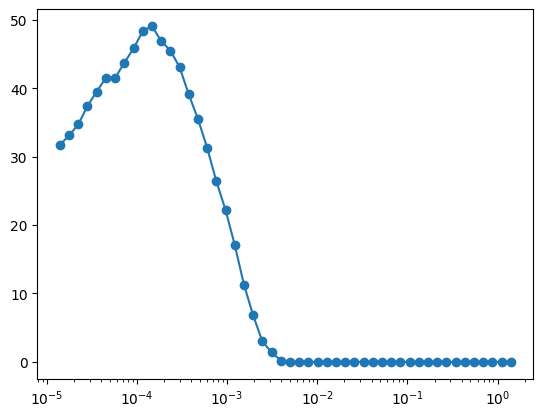

In [2]:
data = np.loadtxt("budget_outputs/N50/out_hybrid_rhos_budg_N50_d_hyb91DVbudget0_NX_wide_ratemin0_10nws.dat")
plt.plot(data[0], data[1], marker='o')
plt.xscale('log')

# Connectivity vs $\rho$ for different DV budgets

Text(0, 0.5, '# candidate DV links')

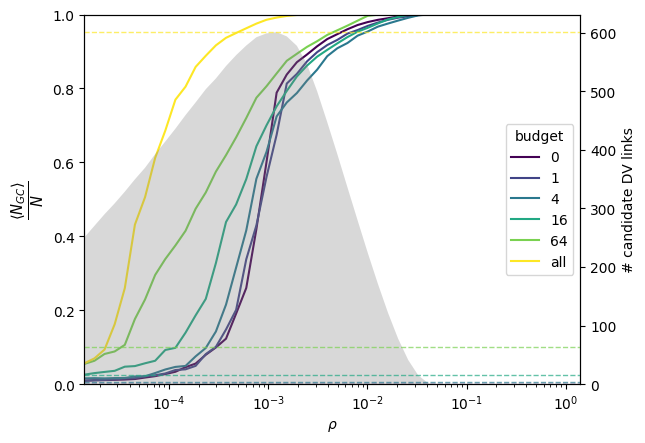

In [34]:
budget_list = [0, 1, 4, 16, 64, np.inf]            # list of numbers of DV edges allowed in the system
N=500

# Collect DV candidate data for averaging
dv_values_list = []
rhos = None
for budget in budget_list:
    num_DV_candidates = np.loadtxt(f"budget_outputs/N{N}/out_hybrid_rhos_budg_N{N}_d_hyb91DVbudget{budget}_NX_wide_ratemin0_10nws.dat")
    if rhos is None:
        rhos = num_DV_candidates[0]
    dv_values_list.append(num_DV_candidates[1])

# Average the DV candidate values
avg_dv_candidates = np.mean(np.array(dv_values_list), axis=0)

# Plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

colors = plt.cm.viridis(np.linspace(0, 1, len(budget_list)))

for i, budget in enumerate(budget_list):
    conn = np.loadtxt(f"budget_outputs/N{N}/out_hybrid_rhos_conn_N{N}_d_hyb91DVbudget{budget}_NX_wide_ratemin0_10nws.dat")
    label = 'all' if budget == np.inf else f'{budget}'
    ax1.plot(conn[0], conn[1], '-', color=colors[i], label=label)
    if budget != np.inf:
        ax2.axhline(y=budget, color=colors[i], linestyle='--', linewidth=1, alpha=0.7)
    else:
        ax2.axhline(y=np.max(avg_dv_candidates), color=colors[i], linestyle='--', linewidth=1, alpha=0.7)

# Plot averaged DV candidates as shaded area on ax2
ax2.fill_between(rhos, 0, avg_dv_candidates, alpha=0.3, color='gray', edgecolor='none')

ax1.legend(title='budget', loc='center right')
ax1.set_xscale('log')
ax1.set_xlim(np.min(rhos), np.max(rhos))
ax1.set_ylim(0.,1.0)
ax2.set_ylim(0., np.amax(avg_dv_candidates)*1.05)
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel(r'$\frac{\langle N_{GC} \rangle}{N}$', fontsize=15)
ax2.set_ylabel('# candidate DV links')